# Проект: Выбор локации для скважины

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте **модель машинного обучения**, которая поможет **определить регион, где добыча принесёт наибольшую прибыль**. **Проанализируйте возможную прибыль и риски** техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.
- Определяют регион с максимальной суммарной прибылью отобранных скважин.

Вам предоставлены пробы нефти в трёх регионах. Характеристики для каждой скважины в регионе уже известны. Постройте модель для определения региона, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой Bootstrap.

Условия задачи:
- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.
- Данные синтетические: детали контрактов и характеристики месторождений не разглашаются.

## Описание данных

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

Данные геологоразведки трёх регионов находятся в файлах: 
1. /datasets/geo_data_0.csv
1. /datasets/geo_data_1.csv
1. /datasets/geo_data_2.csv
- id — уникальный идентификатор скважины;
- f0, f1, f2 — три признака точек (неважно, что они означают, но сами признаки значимы);
- product — объём запасов в скважине (тыс. баррелей).

In [1]:
!pip install phik -q
import phik

In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt 

import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error

import seaborn as sns

from scipy import stats as st


In [4]:
RANDOM_STATE = 42

вспомогательные функции:

In [5]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

# визуализирует все категориальные фичи датафрейма в виде пирогов
# визуализирует все категориальные фичи датафрейма в виде ящиков с усами и гистограмм с распределием, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query(),
#   графики выводятся для каждого фильтра
#   чтобы вывести графики без фильтра нужно передать пустой запрос, или же не передавать фильтры вовсе

def do_categorial_eda(df, filters=[]):
    PIE_WIDTH = 5
    # вывод графиков по категориальным фичам 
    for column in df:
        if df[column].dtype == 'O':
            title0 = f"столбец {column}"
            df_show = df[column]
            if n_filters > 0 and filters[0] != '':
                title = title0 + f"\nфильтр: {filters[0]}"
                df_show = df.query(filters[0])[column]
            if n_filters <= 1:
                ax = df_show.value_counts().plot(title=title0, kind='pie', figsize=(PIE_WIDTH, PIE_WIDTH), autopct=lambda x: f"{x:.0f}%");
                ax.set_ylabel('')
            else:
                fig, axes = plt.subplots(1, n_filters, figsize=(PIE_WIDTH*n_filters, PIE_WIDTH))
                for i in range (n_filters):
                    if filters[i] != '':
                        title = title0 + f"\nфильтр: {filters[i]}"
                        df_show = df.query(filters[i])[column]
                    else:
                        title = title0
                    ax = df_show.value_counts().plot(ax=axes[i], title=title, kind='pie', autopct=lambda x: f"{x:.0f}%");
                    ax.set_ylabel('')
        plt.show();

def do_numbers_eda(df, filters=[]):
    bins=25
    n_filters = len(filters)
    # вывод графиков по числовым фичам 
    if n_filters == 0:
        filters = ['']
        n_filters = 1
    for column in df:
        if column == 'index':
            continue
        if df[column].dtype in ['int64', 'float64'] and column != "id":
            display (f"********** Следующий признак: {column}")
            fig, axs = plt.subplots(nrows=2*max(1, n_filters), ncols=1, figsize=(6, 7*n_filters))
            for i in range (n_filters):
                title = f"столбец {column}"
                df_show = df[column]
                if filters[i] != '':
                    title = title + f", фильтр: {filters[i]}"
                    df_show = df.query(filters[i])[column]
                axs[i*2].boxplot(df_show, vert=False);
                axs[i*2].set_title(title, fontsize=9)
                sns.histplot(df_show, bins=bins, kde=True, ax=axs[i*2+1], alpha=0.8)
                axs[i*2+1].set_xlabel('')
                display(f"фильтр = '{filters[i]}'")
                display(df_show.describe())
            plt.show();

def do_eda(df, filters=[]):
    do_categorial_eda(df, filters())
    do_numbers_eda(df, filters())

def def_load_csv(csv):
    df = pd.read_csv(correct_path(csv))
    display(df.info())
    display(df.head())
    return df

## Загрузка и подготовка данных

In [6]:
df_0 = def_load_csv ('geo_data_0.csv')
df_0['region'] = 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [7]:
df_1 = def_load_csv ('geo_data_1.csv')
df_1['region'] = 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [8]:
df_2 = def_load_csv ('geo_data_2.csv')
df_2['region'] = 2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


- типы данных корректны
- имена полей корректны

Объединим таблицы

In [9]:
df = pd.concat([df_0, df_1, df_2], axis=0).reset_index()
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 7 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   index    300000 non-null  int64  
 1   id       300000 non-null  object 
 2   f0       300000 non-null  float64
 3   f1       300000 non-null  float64
 4   f2       300000 non-null  float64
 5   product  300000 non-null  float64
 6   region   300000 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 16.0+ MB


None

,index,id,f0,f1,f2,product,region
0,0,txEyH,0.705745,-0.497823,1.221170,105.280062,0
1,1,2acmU,1.334711,-0.340164,4.365080,73.037750,0
2,2,409Wp,1.022732,0.151990,1.419926,85.265647,0
3,3,iJLyR,-0.032172,0.139033,2.978566,168.620776,0
4,4,Xdl7t,1.988431,0.155413,4.751769,154.036647,0


- Изучим пропуски

In [10]:
display(df.isna().sum())

index      0
id         0
f0         0
f1         0
f2         0
product    0
region     0
dtype: int64

-- пропусков нет

- Изучим явные дубликаты в датафрейме

In [11]:
display(df.duplicated().sum())

0

-- явных дубликатов не найдено.

In [12]:
df['id'].value_counts().value_counts()

1    299902
2        49
Name: id, dtype: int64

-- странно, почему-то 49 скважин входят по 2 раза

In [13]:
df_0['id'].value_counts()

AGS9W    2
74z30    2
Tdehs    2
TtcGQ    2
QcMuo    2
        ..
uiDea    1
6PRQx    1
OT6vk    1
y1LvX    1
qOMiL    1
Name: id, Length: 99990, dtype: int64

In [14]:
df_0.query('id=="QcMuo"')

,id,f0,f1,f2,product,region
1949,QcMuo,0.506563,-0.323775,-2.215583,75.496502,0
63593,QcMuo,0.635635,-0.473422,0.862670,64.578675,0


📌

-- что ж, видимо из одних и тех же скважин измерения брались несколько раз (возможно в разных условиях f0, f1, f2 вроде глубины/диаметра скважины, давления/скорости поршня и т. п.) - наверное, это нормально, но отразим это наблюдение в отчёте на всякий случай.



- Изучим количественные значения

In [15]:
FEATURES = ['f0', 'f1', 'f2']

### EDA региона 0

'********** Следующий признак: f0'

"фильтр = ''"

count    100000.000000
mean          0.500419
std           0.871832
min          -1.408605
25%          -0.072580
50%           0.502360
75%           1.073581
max           2.362331
Name: f0, dtype: float64

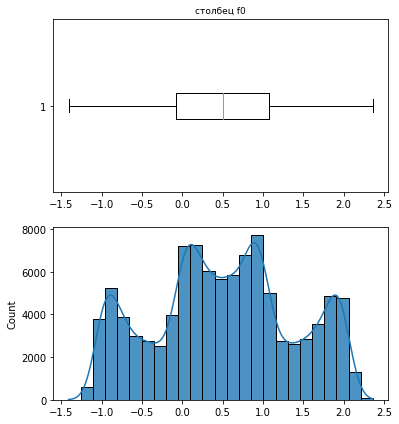

'********** Следующий признак: f1'

"фильтр = ''"

count    100000.000000
mean          0.250143
std           0.504433
min          -0.848218
25%          -0.200881
50%           0.250252
75%           0.700646
max           1.343769
Name: f1, dtype: float64

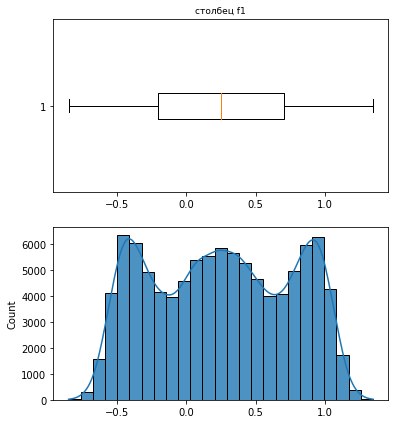

'********** Следующий признак: f2'

"фильтр = ''"

count    100000.000000
mean          2.502647
std           3.248248
min         -12.088328
25%           0.287748
50%           2.515969
75%           4.715088
max          16.003790
Name: f2, dtype: float64

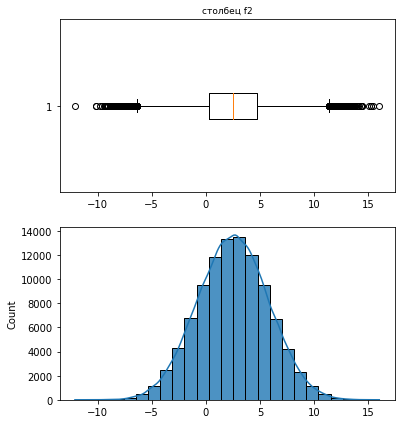

'********** Следующий признак: product'

"фильтр = ''"

count    100000.000000
mean         92.500000
std          44.288691
min           0.000000
25%          56.497507
50%          91.849972
75%         128.564089
max         185.364347
Name: product, dtype: float64

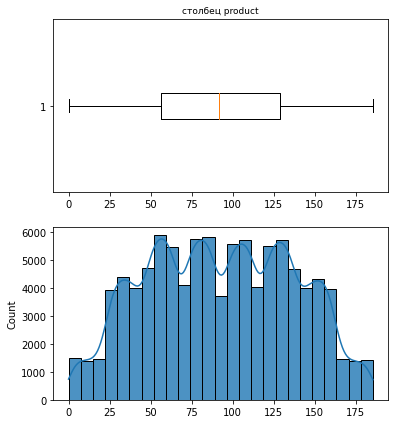

'********** Следующий признак: region'

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    100000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: region, dtype: float64

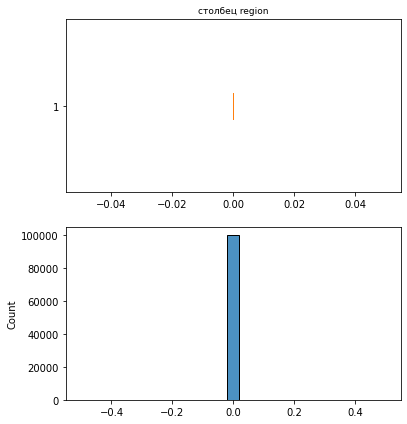

In [18]:
do_numbers_eda(df_0)

interval columns not set, guessing: ['f0', 'f1', 'f2']


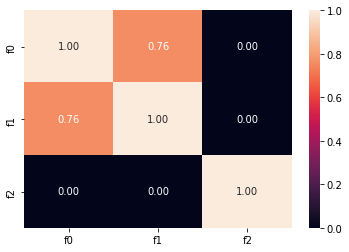

In [19]:
sns.heatmap(df_0[FEATURES].phik_matrix(), annot=True, fmt='.2f');

#### Выводы по региону 0
- f0 - похоже на смесь 5 распределений (5 пиков)
- f1 - похоже на смесь 3 распределений (3 пика)
- f2 - имеет распределение похожее на нормальное
- распределение объёмов запасов отдалённо напоминает нормальное, но видно, что есть явных всплесков - много скважин выдают конкретные объёмы добычи: ~25, ~50, ~110 тыс баррелей - это странно, возможно, это как-то связано с объёмами закупок или доступных хранилищ/танкеров.
- мультиколлинеарности между фичами, на которых планируем обучение - не выявлено

### EDA региона 1

'********** Следующий признак: f0'

"фильтр = ''"

count    100000.000000
mean          1.141296
std           8.965932
min         -31.609576
25%          -6.298551
50%           1.153055
75%           8.621015
max          29.421755
Name: f0, dtype: float64

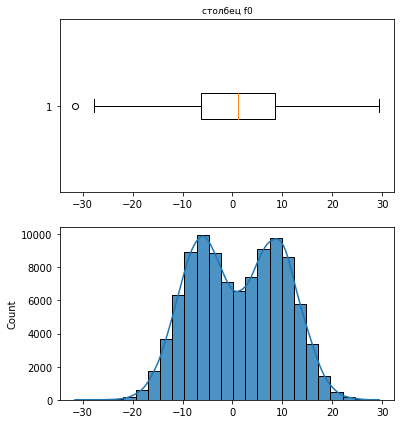

'********** Следующий признак: f1'

"фильтр = ''"

count    100000.000000
mean         -4.796579
std           5.119872
min         -26.358598
25%          -8.267985
50%          -4.813172
75%          -1.332816
max          18.734063
Name: f1, dtype: float64

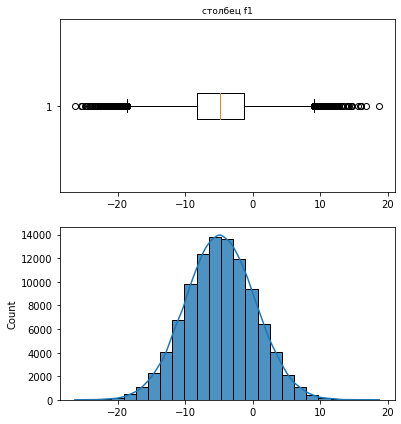

'********** Следующий признак: f2'

"фильтр = ''"

count    100000.000000
mean          2.494541
std           1.703572
min          -0.018144
25%           1.000021
50%           2.011479
75%           3.999904
max           5.019721
Name: f2, dtype: float64

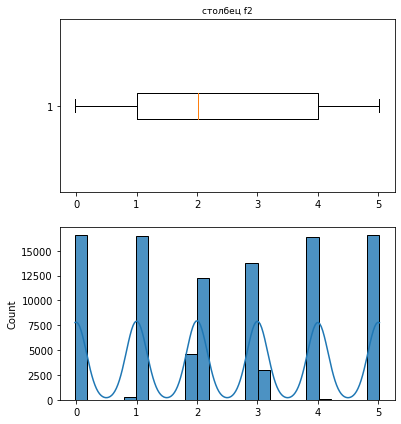

'********** Следующий признак: product'

"фильтр = ''"

count    100000.000000
mean         68.825000
std          45.944423
min           0.000000
25%          26.953261
50%          57.085625
75%         107.813044
max         137.945408
Name: product, dtype: float64

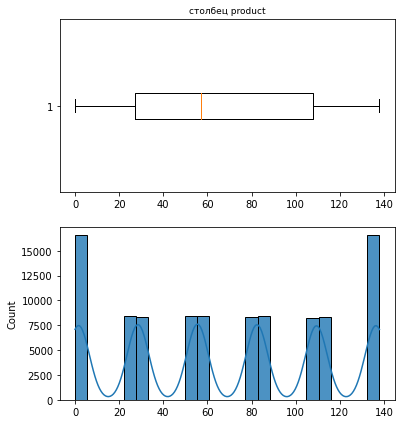

'********** Следующий признак: region'

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    100000.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: region, dtype: float64

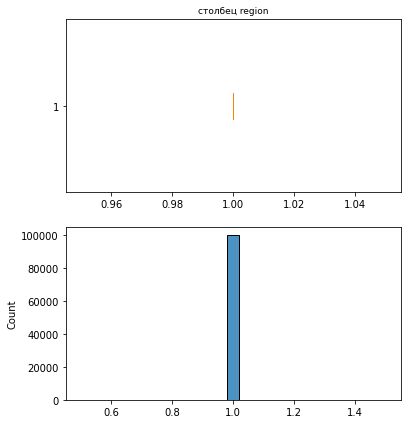

In [20]:
do_numbers_eda(df_1)

interval columns not set, guessing: ['f0', 'f1', 'f2']


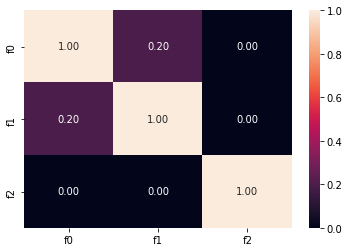

In [21]:
sns.heatmap(df_1[FEATURES].phik_matrix(), annot=True, fmt='.2f');

#### Выводы по региону 1
- f0 - похоже на смесь 2 распределений (2 пика)
- f1 - имеет распределение похожее на нормальное
- f2 - имеет дискретное распределение 
- распределение объёмов запасов - также дискретное
- мультиколлинеарности между фичами, на которых планируем обучение - не выявлено

### EDA региона 2

'********** Следующий признак: f0'

"фильтр = ''"

count    100000.000000
mean          0.002023
std           1.732045
min          -8.760004
25%          -1.162288
50%           0.009424
75%           1.158535
max           7.238262
Name: f0, dtype: float64

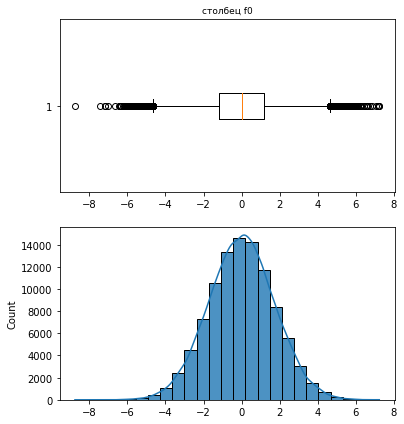

'********** Следующий признак: f1'

"фильтр = ''"

count    100000.000000
mean         -0.002081
std           1.730417
min          -7.084020
25%          -1.174820
50%          -0.009482
75%           1.163678
max           7.844801
Name: f1, dtype: float64

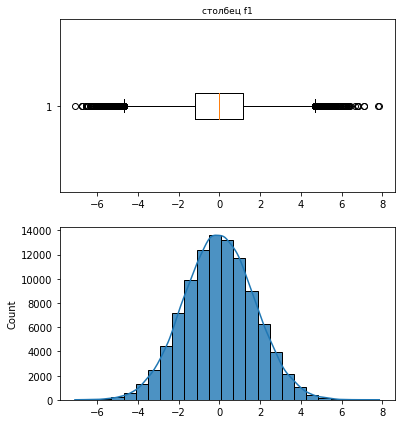

'********** Следующий признак: f2'

"фильтр = ''"

count    100000.000000
mean          2.495128
std           3.473445
min         -11.970335
25%           0.130359
50%           2.484236
75%           4.858794
max          16.739402
Name: f2, dtype: float64

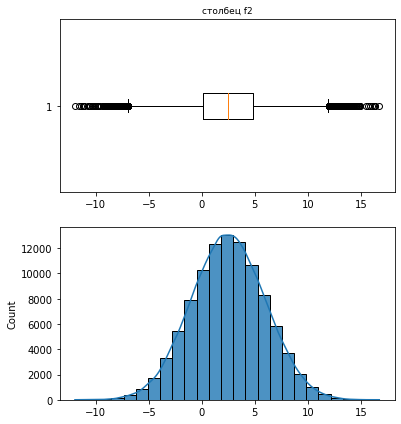

'********** Следующий признак: product'

"фильтр = ''"

count    100000.000000
mean         95.000000
std          44.749921
min           0.000000
25%          59.450441
50%          94.925613
75%         130.595027
max         190.029838
Name: product, dtype: float64

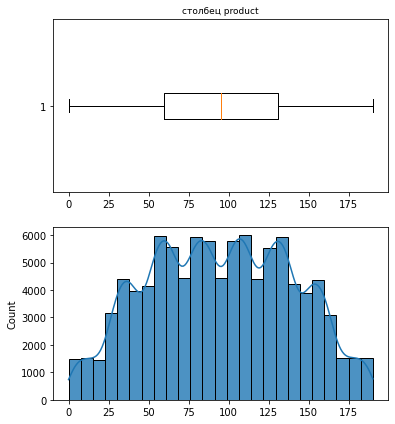

'********** Следующий признак: region'

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:306: UserWarning: Dataset has 0 variance; skipping density estimate.
  warnings.warn(msg, UserWarning)


"фильтр = ''"

count    100000.0
mean          2.0
std           0.0
min           2.0
25%           2.0
50%           2.0
75%           2.0
max           2.0
Name: region, dtype: float64

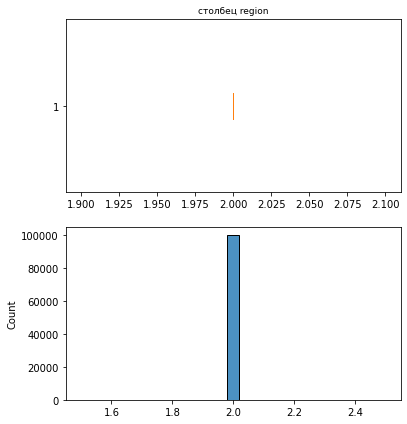

In [22]:
do_numbers_eda(df_2)

interval columns not set, guessing: ['f0', 'f1', 'f2']


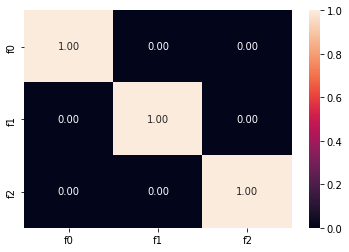

In [23]:
sns.heatmap(df_2[FEATURES].phik_matrix(), annot=True, fmt='.2f');

#### Выводы по региону 2
- f0, f1, f2 - распределения похожи на нормальные
- распределение объёмов запасов отдалённо напоминает нормальное, но видно, что есть явные всплески - это странно, возможно, это как-то связано с объёмами закупок или доступных хранилищ/танкеров.
- мультиколлинеарности между фичами, на которых планируем обучение - не выявлено

### Выводы по EDA
- в разных датасетах одна и та же фича имеет различные распределения, в частности дискретные
    - в дискретности фичи ничего плохого не вижу - фактически, этот признак просто превращается из числового к категориальный
    - но вот то, что одна и так же фича в разных датасетах имеет разное распределение - это может быть плохо, т. к. может быть признаком разнородности данных или ошибки при их сборе (либо при причисление замеров не к своей фиче). Эт как минимум стоит отметить в отчёте. А, возможно, и учесть как-то в обучении (но не знаю пока как)

## Обучение и проверка модели

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

- 2.1. Разбейте данные на обучающую и валидационную выборки в соотношении 75:25.
- 2.2. Обучите модель и сделайте предсказания на валидационной выборке.
- 2.3. Сохраните предсказания и правильные ответы на валидационной выборке.
- 2.4. Напечатайте на экране средний запас предсказанного сырья и RMSE модели.


/tmp/ipykernel_48/2756633967.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[FEATURES] = scaler.fit_transform(X_train[FEATURES])
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

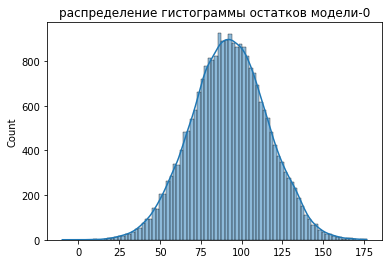

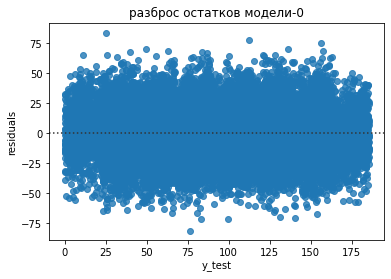

/tmp/ipykernel_48/2756633967.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_test'] = y_test
/tmp/ipykernel_48/2756633967.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_pred'] = y_pred
/tmp/ipykernel_48/2756633967.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

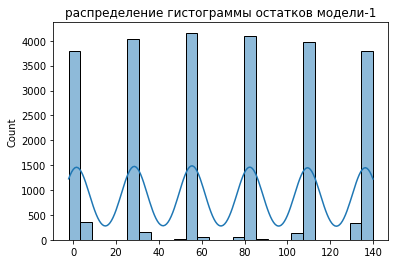

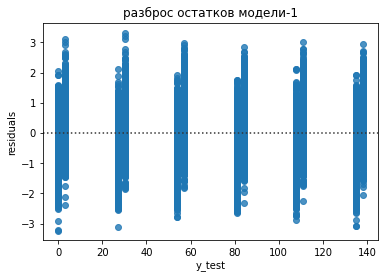

/tmp/ipykernel_48/2756633967.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_test'] = y_test
/tmp/ipykernel_48/2756633967.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_pred'] = y_pred
/tmp/ipykernel_48/2756633967.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#ret

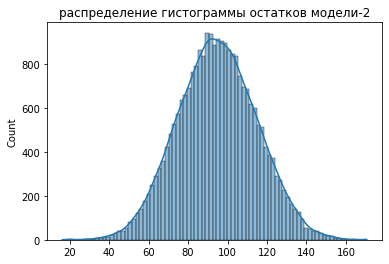

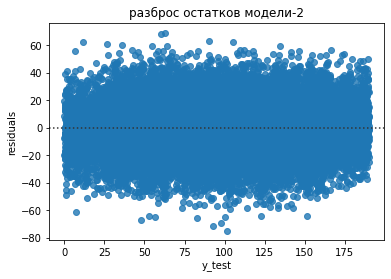

/tmp/ipykernel_48/2756633967.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_test'] = y_test
/tmp/ipykernel_48/2756633967.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['y_pred'] = y_pred


,модель,rmse,средний запас предсказанного сырья
2,модель-2,40.145872,94.771024
0,модель-0,37.756600,92.398800
1,модель-1,0.890280,68.712878


In [24]:
dfs = [df_0, df_1, df_2]
tested_dfs = []
reports = pd.DataFrame( columns=["модель", "rmse",
                                 "средний запас предсказанного сырья"])

for i in range(3):
    X = dfs[i][FEATURES]
    y = dfs[i]['product']
    X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y,
        test_size=0.25,
        random_state=RANDOM_STATE
    )

    scaler = StandardScaler()

    X_train[FEATURES] = scaler.fit_transform(X_train[FEATURES])
    X_test[FEATURES] = scaler.transform(X_test[FEATURES])

    model_lr = LinearRegression()
    model_lr.fit(X_train, y_train)
    y_pred  = model_lr.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    report = {
        "модель": f'модель-{i}',
        "rmse": rmse,
        "средний запас предсказанного сырья": np.mean(y_pred)
    }
    reports = reports.append(report, ignore_index=True)

    residuals = y_test - y_pred

    ax = sns.histplot(data = y_pred, kde = True);
    ax.set_title (f'распределение гистограммы остатков модели-{i}')
    plt.show()

    tmp = pd.DataFrame({'y_test':y_test, 'residuals':residuals})
    ax = sns.residplot(data=tmp, x="y_test", y="residuals");
    ax.set_title (f'разброс остатков модели-{i}')
    plt.show()

    ################
    X_test['y_test'] = y_test
    X_test['y_pred'] = y_pred
    tested_dfs.append (X_test)

reports = reports.sort_values(by='rmse', ascending=False)
display(reports)

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">
2.5. Проанализируйте результаты.

- модель построена для каждого региона:
    - регион-0
        - прогноз среднего запаса наиболее перспективный: 92.40
        - RMSE модели великоват = 37.76 (41% от среднего)
        - распределение и разброс остатков выглядят нормально (без дуг и рупоров)
    - регион-1
        - прогноз среднего запаса наименее перспективный: 68.71
        - RMSE модели = 0.89
        - распределение и разброс остатков выглядят нормально (без дуг и рупоров) - с точностью до природы дискретного распределения
    - регион-2
        - прогноз среднего запаса относительно перспективный: 94.77
        - RMSE модели великоват = 40.14 (42% от среднего)
        - распределение и разброс остатков выглядят нормально (без дуг и рупоров)

PS.В этом месте я захотел попробовать pipeline, но увидел, что у линейной регрессии (которой в задании рекомендуется придерживаться) гиперпараметров для перебора особо и нет.


## Подготовка к расчёту прибыли

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">
Подготовьтесь к расчёту прибыли:

- 3.1. Все ключевые значения для расчётов сохраните в отдельных переменных.
- 3.2. Рассчитайте достаточный объём сырья для безубыточной разработки новой скважины. Сравните полученный объём сырья со средним запасом в каждом регионе. 
- 3.3. Напишите выводы по этапу подготовки расчёта прибыли.


- Бюджет на один регион 10 млрд. рублей
- Выручка составляет 450 тыс. руб. с одной тысячи баррелей.

In [25]:
BUDGET_LIMIT_PER_REGION = 10_000_000_000
PROFIT_PER_1K_BARREL = 450_000
BOOTSTRAP_LEN = 1_000
BOOTSTRAP_SIZE = 500
TOP_N = 200
enough_1k_barrels_per_region = BUDGET_LIMIT_PER_REGION / PROFIT_PER_1K_BARREL

In [26]:
display(f'С любого региона для безубыточности достаточно добывать '
        f'{enough_1k_barrels_per_region:.2f} тыс. баррелей')

'С любого региона для безубыточности достаточно добывать 22222.22 тыс. баррелей'

In [27]:
def print_region_profit_from_df (region, df):
    b = sum(df['product'])
    s = b*PROFIT_PER_1K_BARREL
    conclusion = 'достаточны' if b >= enough_1k_barrels_per_region else 'недостаточны'
    display (f"В регионе {region} запасов {b:,.0f} баррелей на {s:,.0f} рублей"
             f", запасы {conclusion}")

print_region_profit_from_df("0", df_0)
print_region_profit_from_df("1", df_1)
print_region_profit_from_df("2", df_2)

'В регионе 0 запасов 9,250,000 баррелей на 4,162,500,000,000 рублей, запасы достаточны'

'В регионе 1 запасов 6,882,500 баррелей на 3,097,125,000,001 рублей, запасы достаточны'

'В регионе 2 запасов 9,500,000 баррелей на 4,275,000,000,000 рублей, запасы достаточны'

In [28]:
df[FEATURES] = scaler.transform(df[FEATURES])
df['predictions'] = model_lr.predict(df[FEATURES])

Вывод: в любом из трёх регионах, судя по данным датасетов, есть достаточный потенциал для безубыточной добычи. Вопрос в эффективности выборе скважин - для чего и нужна наша модель, и она должна быть достаточно хорошей для этого.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">
Напишите функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:

- 4.1. Выберите скважины с максимальными значениями предсказаний. 
- 4.2. Просуммируйте целевое значение объёма сырья, соответствующее этим предсказаниям.
- 4.3. Рассчитайте прибыль для полученного объёма сырья.



In [29]:
def predict_profit_from_boreholes (data, top_n):
    top_boreholes = data.sort_values(by='y_pred', ascending=False).head(n=top_n)
    # здесь мы проверяем, а какой доход по факту дадут top_n скважин,
    # предсказанных моделью как наиболее объёмные
    return sum(top_boreholes['y_test'])*PROFIT_PER_1K_BARREL - BUDGET_LIMIT_PER_REGION

## Расчёт прибыли и рисков 

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">
Посчитайте риски и прибыль для каждого региона:

- 5.1. Примените технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли.
- 5.2. Найдите среднюю прибыль, 95%-й доверительный интервал и риск убытков. Убыток — это отрицательная прибыль.
- 5.3. Напишите выводы: предложите регион для разработки скважин и обоснуйте выбор.

In [31]:
state = np.random.RandomState(RANDOM_STATE)
results=pd.DataFrame()
for r in range(3):
    profits = []
    for i in range(BOOTSTRAP_LEN):
        sample = tested_dfs[r].sample (BOOTSTRAP_SIZE, replace=True, random_state=state)
        profits.append(predict_profit_from_boreholes (sample, TOP_N))

    profits = pd.Series(profits)
    # строим график распределения
    # https://stackoverflow.com/questions/71296986/how-to-draw-the-probability-density-function-pdf-plot-in-python

##v3        ax = profits.plot(kind = 'density')
##v3        ax.set_title(f"регион {r}")
##v3        plt.show()

##v3    mu = profits.mean()
##v3    sigma = profits.std()
##v3    distr = st.norm(mu, sigma) 
##v3    risk = distr.cdf(0)

    risk = sum(1 for j in profits if j < 0) / len(profits)
    result = {
        "Регион": int(r),
        "Средняя прибыль": profits.mean(),
        "2.5%-квантиль": profits.quantile(0.025),
        "97.5%-квантиль": profits.quantile(0.975),
        "риск убыточности": risk
    }

    results = results.append(result, ignore_index=True) \
        .sort_values(by='Средняя прибыль', ascending=False)

display(results)

,2.5%-квантиль,97.5%-квантиль,Регион,Средняя прибыль,риск убыточности
0,5.230941e+07,8.301463e+08,1.0,4.525766e+08,0.009
1,-1.104679e+08,8.974603e+08,0.0,3.995755e+08,0.060
2,-1.277794e+08,9.079235e+08,2.0,3.787059e+08,0.075


## Выводы
- в предыдущей таблице представлена информация по регионам, из неё видно, что только регион-1 не будет убыточен, с уровнем доверия 97.5%:
    - 95-процентный доверительный интервал суммарной прибыли по региону-1 (2.5%, 97.5%) = (52_309_410 руб, 830_146_300 руб)
    - средняя прибыль по региону-1 = 452_576_600
    - риск убыточности = 0.9%
- RMSE модели-1 = 0.89
- однако у датасета региона-1 и модели-1:
    - f0 - похоже на смесь 2 распределений (2 пика)
    - f1 - имеет распределение похожее на нормальное
    - f2 - имеет дискретное распределение 
    - распределение объёмов запасов - также дискретное    
    - распределение остатков модели-1 дискретное
    - **всё это выглядит странным, но не могу этого обосновать - видимо, требуется помощь ревьюера**
- попутные наблюдения:
    - мультиколлинеарности между фичами, на которых планируем обучение - не выявлено
    - для сведения заказчика: в датасетах найдено 49 случая, когда замер был взят их одной скважины дважды (с разными f0,f1,f2)

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован